# EDA, Preprocessing & Classical ML Baselines
## Customer Support Intent Classification

In [1]:
import subprocess, sys
pkgs = ["scikit-learn", "pandas", "numpy", "matplotlib", "plotly", "requests"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Packages installed")

Packages installed


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os, gc, time, random
import numpy as np
import pandas as pd
import re, time, requests, io

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = "plotly_white"

from scipy.special import softmax

from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras import backend as K

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

This helper block defines utility functions to format notebook output and preview DataFrames more clearly.
It also sets reusable color palettes for plots and prints a confirmation message when the setup is ready.

In [3]:
# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------
def section(title: str):
    """Print a formatted section header."""
    print("\n" + "=" * 95)
    print(title)
    print("=" * 95)

def print_df(df: pd.DataFrame, name: str, n: int = 10):
    """Print a summary and top rows of a DataFrame."""
    print("\n" + "-" * 95)
    print(f"[DATAFRAME] {name} | shape = {df.shape[0]:,} rows × {df.shape[1]:,} cols")
    print("-" * 95)
    print(df.head(n).to_string())

COLORS_BINARY   = {"0": "#2E86AB", "1": "#D1495B"}
COLORS_SEQ      = px.colors.qualitative.Set2
COLORS_MULTI    = px.colors.qualitative.Set3 + px.colors.qualitative.Dark24
C_BLUE, C_RED   = "steelblue", "#D1495B"

print("Helpers ready ✓")

Helpers ready ✓


In [4]:
# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
RANDOM_STATE = 42
TARGET       = "intent"
FEATURE_COL  = "instruction"

print(f"Target  : {TARGET}")
print(f"Feature : {FEATURE_COL}")

Target  : intent
Feature : instruction


## Step 1 — Problem Definition & Dataset

**Dataset:** Bitext Customer Support LLM Chatbot Training Dataset, loaded from HuggingFace (~27,000 samples).

**Target variable (Y):** `intent` — 27 distinct customer intent classes (e.g. cancel_order, get_refund, track_order). This is a multi-class classification problem with 27 possible output labels.

**Input feature (X):** `instruction` — a free-text customer utterance (e.g. "I need to cancel my order"). This is the only input feature used. No structured or numerical features are present in this dataset.

**Why this target:** The intent label directly captures what the customer wants to achieve. Predicting it correctly allows a support system to route the customer to the right response or agent automatically.

**Why this input:** The raw customer utterance contains all available signal. No metadata (e.g. account history, product type) is available — the model must classify intent from text alone.

**Task type:** Multi-class text classification — 27 mutually exclusive classes, one prediction per utterance.

In [5]:
# =============================================================================
# LOAD DATA
# =============================================================================
section("Load dataset from HuggingFace")

def load_bitext() -> pd.DataFrame:
    api = ("https://datasets-server.huggingface.co/parquet"
           "?dataset=bitext/Bitext-customer-support-llm-chatbot-training-dataset")
    resp = requests.get(api, timeout=30)
    resp.raise_for_status()
    url = resp.json()["parquet_files"][0]["url"]
    print(f"Downloading parquet: {url}")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    return pd.read_parquet(io.BytesIO(r.content))

df = load_bitext()
print_df(df, "Bitext raw")


Load dataset from HuggingFace

-----------------------------------------------------------------------------------------------
[DATAFRAME] Bitext raw | shape = 26,872 rows × 5 cols
-----------------------------------------------------------------------------------------------
   flags                                                   instruction category        intent                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

## Step 2 — Exploratory Data Analysis

### 1. Dataset Overview
**Checking for:** Shape, column types, missing values, duplicates.

**Findings:** 4 columns — instruction (input), intent (target), category (grouping), flags (linguistic variation). No missing values, no duplicates.

In [6]:
# =============================================================================
# DATASET OVERVIEW
# =============================================================================
section("Dataset overview")

print(f"Shape      : {df.shape[0]:,} rows × {df.shape[1]:,} cols")
print(f"Columns    : {list(df.columns)}")
print(f"Missing    : {df.isnull().sum().to_dict()}")
print(f"Duplicates : {df.duplicated().sum()}")
print()
print(df.dtypes.to_string())


Dataset overview
Shape      : 26,872 rows × 5 cols
Columns    : ['flags', 'instruction', 'category', 'intent', 'response']
Missing    : {'flags': 0, 'instruction': 0, 'category': 0, 'intent': 0, 'response': 0}
Duplicates : 0

flags          object
instruction    object
category       object
intent         object
response       object


### 2. Class Distribution
**Checking for:** Balance across all 27 intent classes.

**Findings:** Dataset is synthetically generated — near-perfect balance of ~1,000 samples per class. No class weighting or resampling required. Macro F1 is the appropriate primary metric as it treats all 27 classes equally.

In [7]:
# =============================================================================
# TARGET DISTRIBUTION — 27 INTENT CLASSES
# =============================================================================
section("Target distribution (intent classes)")

vc = df[TARGET].value_counts().reset_index()
vc.columns = ["intent", "count"]
vc["pct"] = (vc["count"] / len(df) * 100).round(2)

print(vc.to_string(index=False))
print(f"\nUnique intents : {df[TARGET].nunique()}")
print(f"Min per class  : {vc['count'].min()}")
print(f"Max per class  : {vc['count'].max()}")
print(f"Mean per class : {vc['count'].mean():.1f}")

fig = px.bar(
    vc.sort_values("count"),
    x="count", y="intent",
    orientation="h",
    title="Intent class distribution — all 27 classes",
    color="count",
    color_continuous_scale="Blues",
    labels={"count": "Number of samples", "intent": "Intent"}
)
fig.update_layout(title_x=0.02, height=700, yaxis_title=None)
fig.show()


Target distribution (intent classes)
                  intent  count  pct
contact_customer_service   1000 3.72
               complaint   1000 3.72
           check_invoice   1000 3.72
          switch_account   1000 3.72
            edit_account   1000 3.72
     contact_human_agent    999 3.72
   check_payment_methods    999 3.72
         delivery_period    999 3.72
 newsletter_subscription    999 3.72
             get_invoice    999 3.72
           payment_issue    999 3.72
   registration_problems    999 3.72
            cancel_order    998 3.71
             place_order    998 3.71
            track_refund    998 3.71
            change_order    997 3.71
 set_up_shipping_address    997 3.71
     check_refund_policy    997 3.71
          create_account    997 3.71
              get_refund    997 3.71
                  review    997 3.71
        delivery_options    995 3.70
          delete_account    995 3.70
        recover_password    995 3.70
             track_order    995 3.70


### 3. Category Distribution
**Checking for:** How the 27 intents group into 10 high-level categories.

**Model signals:** Categories with multiple similar intents (e.g. ORDER contains cancel_order and change_order) will produce the most confusion — confirmed in the confusion matrix later.

In [8]:
# =============================================================================
# CATEGORY DISTRIBUTION (10 HIGH-LEVEL GROUPS)
# =============================================================================
section("Category distribution")

cat_vc = df["category"].value_counts().reset_index()
cat_vc.columns = ["category", "count"]

fig = px.bar(
    cat_vc,
    x="category", y="count",
    title="Sample count by category (high-level groups)",
    color="category",
    color_discrete_sequence=COLORS_SEQ,
    labels={"count": "Count", "category": "Category"}
)
fig.update_layout(title_x=0.02, showlegend=False, xaxis_tickangle=-30)
fig.show()

print(cat_vc.to_string(index=False))


Category distribution


    category  count
     ACCOUNT   5986
       ORDER   3988
      REFUND   2992
     CONTACT   1999
     INVOICE   1999
     PAYMENT   1998
    FEEDBACK   1997
    DELIVERY   1994
    SHIPPING   1970
SUBSCRIPTION    999
      CANCEL    950


### 4. Text Length Distribution
**Checking for:** Utterance length in words and characters.

**Model signals:** Median ~8 words. Short text weakens bag-of-words models as there are fewer discriminating terms per sample. Transformer models handle short sequences natively without truncation.

In [9]:
# =============================================================================
# TEXT LENGTH ANALYSIS
# =============================================================================
section("Text length analysis")

df["n_chars"] = df[FEATURE_COL].str.len()
df["n_words"] = df[FEATURE_COL].str.split().str.len()

print("-" * 80)
print(df[["n_chars", "n_words"]].describe().round(2).to_string())

fig = px.histogram(
    df, x="n_chars", nbins=60,
    title="Instruction — character length distribution",
    labels={"n_chars": "Character length", "count": "Count"}
)
fig.update_traces(marker_color=C_BLUE)
fig.update_layout(bargap=0.05, title_x=0.02)
fig.show()

fig = px.histogram(
    df, x="n_words", nbins=40,
    title="Instruction — word count distribution",
    labels={"n_words": "Word count", "count": "Count"}
)
fig.update_traces(marker_color=C_RED)
fig.update_layout(bargap=0.05, title_x=0.02)
fig.show()

fig = px.box(
    df, y="n_words", x="category",
    title="Word count by category",
    color="category",
    color_discrete_sequence=COLORS_SEQ
)
fig.update_layout(title_x=0.02, xaxis_tickangle=-30, showlegend=False)
fig.show()


Text length analysis
--------------------------------------------------------------------------------
        n_chars   n_words
count  26872.00  26872.00
mean      46.89      8.69
std       10.90      2.61
min        6.00      1.00
25%       40.00      7.00
50%       48.00      9.00
75%       55.00     11.00
max       92.00     16.00


### 5. Linguistic Variation Flags
**Checking for:** Distribution of variation types — B (Basic), C (Colloquial), M (Misspelled), P (Politeness), Q (Question), W (Offensive).

**Model signals:** M (Misspelled) flags are the key robustness test — models that degrade on misspelled utterances would not be suitable for real deployment. Analysed in depth in Notebook 4.

In [10]:
# =============================================================================
# LINGUISTIC VARIATION FLAGS
# =============================================================================
section("Linguistic variation flags")

# B=Basic, C=Colloquial, M=Misspelled, P=Politeness, Q=Question, W=Offensive
flag_map = {"B": "Basic", "C": "Colloquial", "M": "Misspelled",
            "P": "Politeness", "Q": "Question-like", "W": "Offensive"}

for code_, label in flag_map.items():
    df[f"flag_{code_}"] = df["flags"].str.contains(code_, na=False).astype(int)

flag_sums = pd.DataFrame({
    "Flag": list(flag_map.values()),
    "Count": [df[f"flag_{c}"].sum() for c in flag_map]
}).sort_values("Count", ascending=False)

flag_sums["Pct"] = (flag_sums["Count"] / len(df) * 100).round(2)

print(flag_sums.to_string(index=False))

fig = px.bar(
    flag_sums,
    x="Flag", y="Count",
    title="Linguistic variation flag frequency",
    color="Flag",
    color_discrete_sequence=COLORS_MULTI,
    labels={"Count": "Number of samples"}
)
fig.update_layout(title_x=0.02, showlegend=False)
fig.show()


Linguistic variation flags
         Flag  Count    Pct
        Basic  26872 100.00
Question-like   8968  33.37
   Misspelled   4920  18.31
   Colloquial   2646   9.85
   Politeness   1329   4.95
    Offensive   1288   4.79


In [11]:
# =============================================================================
# DEFAULT RATE EQUIVALENT — INTENT RATE BY CATEGORY
# =============================================================================
section("Intent spread per category")

intent_cat = (
    df.groupby("category")["intent"]
      .nunique()
      .reset_index()
      .rename(columns={"intent": "unique_intents"})
      .sort_values("unique_intents", ascending=False)
)

styled_table = (
    intent_cat.style
    .background_gradient(subset=["unique_intents"], cmap="Blues")
    .set_properties(**{
        "background-color": "white",
        "color": "black",
        "border-color": "black"
    })
)
styled_table


Intent spread per category


,category,unique_intents
0,ACCOUNT,6
6,ORDER,4
8,REFUND,3
5,INVOICE,2
2,CONTACT,2
4,FEEDBACK,2
3,DELIVERY,2
9,SHIPPING,2
7,PAYMENT,2
1,CANCEL,1


### 6. Sample Utterances
**Checking for:** Vocabulary overlap between similar intents.

**Key finding:** cancel_order and change_order share keywords such as order, cancel, change. This overlap is the primary source of confusion matrix off-diagonal entries and appears across all model tiers.

In [12]:
# =============================================================================
# SAMPLE UTTERANCES PER INTENT
# =============================================================================
section("Sample utterances per intent (3 examples each)")

sample_intents = ["cancel_order", "track_order", "get_refund",
                  "contact_human_agent", "complaint"]
for intent_name in sample_intents:
    print("\n" + "-" * 80)
    print(f"{intent_name.upper()}")
    samples = df[df[TARGET] == intent_name][FEATURE_COL].sample(3, random_state=42).tolist()
    for s in samples:
        print(f"  • {s}")


Sample utterances per intent (3 examples each)

--------------------------------------------------------------------------------
CANCEL_ORDER
  • I cannot afford purchase {{Order Number}}
  • I have bought some item, I have to cancel order {{Order Number}}
  • I do not want this item, cancel order {{Order Number}}

--------------------------------------------------------------------------------
TRACK_ORDER
  • where to see the bloody ETA of the order {{Order Number}}
  • checking status of order {{Order Number}}
  • see purchase {{Order Number}} current status

--------------------------------------------------------------------------------
GET_REFUND
  • I paid {{Currency Symbol}}{{Refund Amount}} for this product, I need to get a rebate
  • I am trying to receive a compensation
  • i need assistance demanding compensations of my money

--------------------------------------------------------------------------------
CONTACT_HUMAN_AGENT
  • I can't speak iwth an operator
  • I want he

### 7. Top Words per Intent
**Checking for:** Whether each intent has a sufficiently distinct vocabulary for bag-of-words separation.

**Model signals:** Intents with unique top words achieve high F1 across all models. Intents sharing top words with neighbours produce low F1 — particularly for TF-IDF-based classical ML.

In [13]:
# =============================================================================
# TOP WORDS PER INTENT — TERM FREQUENCY OVERVIEW
# =============================================================================
section("Most common words per intent (top 3 intents by size)")

from collections import Counter

top_intents = df[TARGET].value_counts().head(3).index.tolist()
for intent_name in top_intents:
    subset = df[df[TARGET] == intent_name][FEATURE_COL]
    words = " ".join(subset).lower().split()
    stopwords = {"i", "my", "to", "the", "a", "an", "is", "it", "me", "can", "you"}
    words = [w for w in words if w not in stopwords and len(w) > 2]
    common = Counter(words).most_common(10)
    common_df = pd.DataFrame(common, columns=["word", "freq"])

    fig = px.bar(
        common_df, x="freq", y="word", orientation="h",
        title=f"Top words — {intent_name}",
        color="freq",
        color_continuous_scale="Blues",
        labels={"freq": "Frequency", "word": "Word"}
    )
    fig.update_layout(title_x=0.02, yaxis={"categoryorder": "total ascending"},
                      showlegend=False, height=350)
    fig.show()


Most common words per intent (top 3 intents by size)


## Step 3 — Feature Engineering & Representation

Text cannot be fed directly into any model — it must first be converted to numbers.
Three different representations are built for the two model tiers.

**Key constraint:** All transformations fitted on training data only — applied to val/test separately to prevent data leakage.

### 8. Text Cleaning

**Why clean text before modelling?** Raw customer utterances contain noise — mixed case, punctuation, URLs — that adds vocabulary size without adding discriminative signal. Reducing noise improves model generalisation.

**Decisions made and why:**

| Decision | Justification |
|----------|---------------|
| Lowercase | "Cancel" and "cancel" are the same word. Lowercasing reduces vocabulary size without losing meaning |
| Remove URLs | No URLs appear in customer utterances but included as a defensive step |
| Remove special characters | Punctuation (!, ?, .) adds noise without adding intent signal for classification |
| Normalise whitespace | Prevents tokenisation errors from extra spaces or newlines |
| Stemming / lemmatisation | TF-IDF with bigrams preserves enough morphological information. Stemming risks collapsing intent-relevant distinctions — e.g. "ordering" vs "ordered" |
| Stop word removal | Short utterances have few words — removing stop words could discard useful context (e.g. "I can't" vs "I can") |

In [14]:
# =============================================================================
# TEXT CLEANING
# =============================================================================
section("Text cleaning")

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+", "", t)          # remove URLs
    t = re.sub(r"[^a-z0-9\s]", " ", t)    # remove special chars
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["text_clean"] = df[FEATURE_COL].apply(clean_text)

# Show before / after
print("-" * 80)
for i in range(3):
    print(f"RAW  : {df[FEATURE_COL].iloc[i]}")
    print(f"CLEAN: {df['text_clean'].iloc[i]}")
    print()


Text cleaning
--------------------------------------------------------------------------------
RAW  : question about cancelling order {{Order Number}}
CLEAN: question about cancelling order order number

RAW  : i have a question about cancelling oorder {{Order Number}}
CLEAN: i have a question about cancelling oorder order number

RAW  : i need help cancelling puchase {{Order Number}}
CLEAN: i need help cancelling puchase order number



### 9. Label Encoding

**Why:** Models require numerical labels, not strings. The intent column contains 27 text class names converted to integers 0–26.

**Method:** LabelEncoder — alphabetical ordering. Same encoder object reused across all notebooks for consistent label-to-intent mapping.

**Leakage check** — fitted on full label set (all 27 classes known upfront), no data leakage risk.


In [15]:
# =============================================================================
# LABEL ENCODING
# =============================================================================
section("Label encoding")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df[TARGET])
NUM_CLASSES = len(le.classes_)

print(f"Classes : {NUM_CLASSES}")
print("\nIntent → Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i:2d} → {cls}")


Label encoding
Classes : 27

Intent → Label mapping:
   0 → cancel_order
   1 → change_order
   2 → change_shipping_address
   3 → check_cancellation_fee
   4 → check_invoice
   5 → check_payment_methods
   6 → check_refund_policy
   7 → complaint
   8 → contact_customer_service
   9 → contact_human_agent
  10 → create_account
  11 → delete_account
  12 → delivery_options
  13 → delivery_period
  14 → edit_account
  15 → get_invoice
  16 → get_refund
  17 → newsletter_subscription
  18 → payment_issue
  19 → place_order
  20 → recover_password
  21 → registration_problems
  22 → review
  23 → set_up_shipping_address
  24 → switch_account
  25 → track_order
  26 → track_refund


### 10. Train / Validation / Test Split — 70 / 15 / 15

**split the data** To evaluate whether a model generalises to unseen examples. Training and evaluating on the same data produces misleadingly high metrics — the model may have simply memorised the training examples.

**Split rationale:**

| Split | Size | Purpose |
|-------|------|---------|
| Train (70%) | ~18,900 samples | Model training — ~700 examples per class |
| Validation (15%) | ~4,050 samples | Hyperparameter tuning and early stopping — never used for final metrics |
| Test (15%) | ~4,050 samples | Final evaluation — used exactly once per model, never during training |

**stratified:** With 27 classes, a random split risks some splits receiving zero samples for a particular intent. Stratification guarantees all 27 classes are proportionally represented in every split — essential for reliable evaluation.

**70/15/15:** 70% training provides ~700 samples per class — sufficient for classical ML and marginal for deep learning. Splitting the remaining 30% equally between validation and test gives balanced tuning and evaluation sets.

In [16]:
# =============================================================================
# STRATIFIED TRAIN / VALIDATION / TEST SPLIT  70 / 15 / 15
# =============================================================================
section("Train / val / test split")

from sklearn.model_selection import train_test_split

X = df["text_clean"].values
y = df["label"].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Train : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val):,} samples  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):,} samples  ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total : {len(X):,}")
print(f"\nClasses in train: {len(np.unique(y_train))} | val: {len(np.unique(y_val))} | test: {len(np.unique(y_test))}")


Train / val / test split
Train : 18,809 samples (70.0%)
Val   : 4,032 samples  (15.0%)
Test  : 4,031 samples  (15.0%)
Total : 26,872

Classes in train: 27 | val: 27 | test: 27


---
### Feature Engineering — Deep Learning (BiLSTM, GRU)

Deep learning models (BiLSTM, GRU) require text converted to padded integer sequences fed through an embedding layer — not raw text strings.

**Why pretrained GloVe instead of random embeddings?**
With only ~700 training samples per class, the model does not have enough data to learn word meanings from scratch. GloVe vectors were pretrained on 6 billion words — they already know that "cancel" and "cancellation" are related before training even starts. The notebook will still run without GloVe (falls back to random initialisation) but results will be weaker.

**Two conditions tested for BiLSTM:**
- Frozen — GloVe weights fixed, pretrained knowledge preserved
- Fine-tuned — weights updated during training, adapts to customer support domain

In [17]:
# =============================================================================
# FEATURE ENGINEERING — Deep Learning: BiLSTM, GRU
# Tokenisation + padding + GloVe embedding matrix
# =============================================================================
section("Tokenisation & padding — for NB3 Deep Learning")

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

MAX_VOCAB = 30_000
MAX_LEN   = 50
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)  # fit on train only

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding="post", truncating="post")
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),
                             maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding="post", truncating="post")

print(f"Vocabulary size  : {len(tokenizer.word_index):,}")
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"max_len=50 covers 95th percentile of utterance lengths from EDA")
print("\n Used by: NB3 (BiLSTM, GRU)")


Tokenisation & padding — for NB3 Deep Learning
Vocabulary size  : 2,368
X_train_seq shape: (18809, 50)
max_len=50 covers 95th percentile of utterance lengths from EDA

 Used by: NB3 (BiLSTM, GRU)


### Why GloVe Embeddings?

BiLSTM and GRU cannot read text — they need numbers. Each word is first
converted to an integer index (e.g. "cancel" → 452). The embedding layer
then maps that index to a dense vector of 100 numbers that the model can
learn from.

The simplest approach would be to start with random vectors and let the
model figure out word meanings during training. The problem is that with
only ~700 training samples per intent class, there is not enough data to
learn what words mean from scratch — the model would not converge well.

**GloVe provides pretrained vectors** where similar words are already close
together in vector space, learned from 6 billion words (Wikipedia +
Gigaword) before training even starts:

- "cancel" and "cancellation" → similar vectors
- "refund" and "money back" → similar vectors
- "cancel" and "invoice" → very different vectors

This gives the model a semantic head start instead of starting from zero.

**GloVe is not strictly required** — the notebook will still run without it.
If the GloVe file is not downloaded, the code automatically falls back to
random initialisation and BiLSTM and GRU will still train. Results will
be a few percentage points lower but nothing will break.

**Two conditions are tested:**

| Condition | Embedding weights | What it tests |
|-----------|------------------|---------------|
| Frozen | Fixed — pretrained GloVe knowledge preserved | Is pretrained knowledge alone sufficient? |
| Fine-tuned | Updated during training | Does adapting GloVe to customer support language improve F1? |

Fine-tuned is expected to outperform frozen — GloVe was trained on
Wikipedia, not customer support conversations. Allowing the weights to
adjust gives the model a head start AND domain adaptation.

In [18]:
# =============================================================================
# GLOVE EMBEDDING MATRIX
# Download glove.6B.zip from http://nlp.stanford.edu/data/glove.6B.zip
# =============================================================================
section("GloVe embedding matrix — for NB3 Deep Learning")

GLOVE_PATH = "glove.6B.100d.txt"
embeddings_index = {}
try:
    with open(GLOVE_PATH, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            embeddings_index[values[0]] = np.asarray(values[1:], dtype="float32")
    print(f"GloVe vectors loaded: {len(embeddings_index):,}")
except FileNotFoundError:
    print(" GloVe file not found — using random initialisation as fallback")
    print("    Download: wget http://nlp.stanford.edu/data/glove.6B.zip && unzip glove.6B.zip")

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index)) + 1
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
for word, idx in tokenizer.word_index.items():
    if idx < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

oov = np.sum(np.all(embedding_matrix[1:]==0, axis=1)) / (vocab_size-1)
print(f"Embedding matrix : {embedding_matrix.shape}")
print(f"OOV rate         : {oov:.2%} (words with no GloVe vector)")
print("\nUsed by: NB3 (BiLSTM, GRU) — frozen and fine-tuned conditions")


GloVe embedding matrix — for NB3 Deep Learning
 GloVe file not found — using random initialisation as fallback
    Download: wget http://nlp.stanford.edu/data/glove.6B.zip && unzip glove.6B.zip
Embedding matrix : (2369, 100)
OOV rate         : 100.00% (words with no GloVe vector)

Used by: NB3 (BiLSTM, GRU) — frozen and fine-tuned conditions


### Shared Evaluation Helper

`get_metrics()` is defined here once so all three model notebooks use
the exact same function and return results in the same format.
This ensures NB5 can combine results from all three without any
manual editing.

Returns: `accuracy | precision | recall | f1 | roc_auc`

**Note for LinearSVC (NB2):** LinearSVC has no `predict_proba` — it uses
`decision_function` scores instead. These do not sum to 1 so they cannot
be passed directly to `roc_auc_score`. The function detects this
automatically and applies softmax to convert them to pseudo-probabilities
before computing ROC-AUC.

In [33]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)

results = {}

def get_metrics(y_true, y_pred, y_proba, model_name, tier, time_s):
    scores = np.array(y_proba)
    if not np.allclose(scores.sum(axis=1), 1.0, atol=1e-3):
        scores = softmax(scores, axis=1)
    m = {
        "model":     model_name,
        "tier":      tier,
        "time_s":    round(time_s, 1),
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1":        f1_score(y_true, y_pred, average="macro"),
        "roc_auc":   roc_auc_score(y_true, scores, multi_class="ovr", average="macro")
    }
    print(f"\n{model_name} — Test results:")
    for k,v in m.items():
        if k not in ["model","tier","time_s"]: print(f"  {k:12}: {v:.4f}")
    return m

def plot_history(history, model_name):
  import matplotlib.pyplot as plt

  plt.plot(history.history["loss"], label= "Train Loss")
  plt.plot(history.history["val_loss"], label= "Val Loss")
  plt.title(f"{model_name} — Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

print("get_metrics() ready — accuracy | precision | recall | f1 | roc_auc")

get_metrics() ready — accuracy | precision | recall | f1 | roc_auc


# << Mohamed Ibrahim - Updates >>

### Build the BiLSTM model

Below step is to define a reusable function that creates the BiLSTM classifier. The model uses an embedding layer, a bidirectional LSTM encoder, a pooling layer, and a dense classification head.

This structure is suitable for customer-support text because the meaning of a sentence often depends on both earlier and later words in the sequence.

In [20]:
# =============================================================================
# BILSTM MODEL BUILDER
# =============================================================================
section("Define BiLSTM model")

def build_bilstm_model(
    lstm_units=128,
    dense_units=64,
    lstm_dropout=0.2,
    dense_dropout=0.4,
    spatial_dropout=0.2,
    learning_rate=1e-3,
    trainable_embeddings=False
):
    """
    Build a BiLSTM text classifier using the existing notebook variables.
    """

    # If GloVe is unavailable, embeddings must be trainable
    effective_trainable = trainable_embeddings if HAS_GLOVE else True

    model = models.Sequential(name="BiLSTM_classifier")

    # Input = padded sequence of token ids
    model.add(layers.Input(shape=(MAX_LEN,), name="input_ids"))

    # Embedding layer
    if HAS_GLOVE:
        model.add(
            layers.Embedding(
                input_dim=vocab_size,
                output_dim=EMBED_DIM,
                weights=[embedding_matrix],
                trainable=effective_trainable,
                mask_zero=True,
                name="embedding"
            )
        )
    else:
        model.add(
            layers.Embedding(
                input_dim=vocab_size,
                output_dim=EMBED_DIM,
                trainable=True,
                mask_zero=True,
                name="embedding"
            )
        )

    # Regularisation at the embedding level
    model.add(layers.SpatialDropout1D(spatial_dropout, name="spatial_dropout"))

    # Bidirectional LSTM
    model.add(
        layers.Bidirectional(
            layers.LSTM(
                lstm_units,
                dropout=lstm_dropout,
                return_sequences=True
            ),
            name="bilstm"
        )
    )

    # Pool strongest signal across the sequence
    model.add(layers.GlobalMaxPooling1D(name="global_max_pool"))

    # Dense classification head
    model.add(layers.Dense(dense_units, activation="relu", name="dense_relu"))
    model.add(layers.Dropout(dense_dropout, name="dense_dropout"))

    # Final multi-class classifier
    model.add(layers.Dense(NUM_CLASSES, activation="softmax", name="classifier"))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("build_bilstm_model() ready ✓")


Define BiLSTM model
build_bilstm_model() ready ✓


### Why this BiLSTM architecture was chosen

This architecture was selected because it is *appropriate for multi-class text classification.*

The embedding layer converts token IDs into dense vector representations. If GloVe vectors are available, the model starts from pretrained semantic information. The parameter trainable_embeddings allows the experiment to compare frozen embeddings against fine-tuned embeddings.

**SpatialDropout1D** is used to improve generalisation by dropping parts of embedding features during training.

The Bidirectional LSTM reads the message in both directions. This is useful because important intent cues may appear at the beginning, middle, or end of a customer message.

**GlobalMaxPooling1D** reduces the sequence output into one fixed-size vector by keeping the strongest feature activations. This often works well for intent classification because a few important words or phrases can be highly informative.

The output layer uses softmax because this is a multi-class classification problem with NUM_CLASSES intent labels.

The loss function is sparse categorical cross-entropy because the target labels are already integer encoded rather than one-hot encoded.

### Training helper for BiLSTM experiments

The following function trains one BiLSTM configuration and returns:

1. The trained model
2. The training history
3. The training history
4. A validation summary used for hyperparameter tuning
the total training time

The validation metrics are computed directly inside the function so that the shared helper get_metrics() can remain the common final evaluation function for all models.

In [21]:
# =============================================================================
# TRAINING HELPER FOR BILSTM
# =============================================================================
section("BiLSTM training helper")

def train_one_bilstm(config, verbose=0):
    """
    Train one BiLSTM configuration and evaluate it on the validation set.
    Returns model, history, validation summary, and training time.
    """
    K.clear_session()
    gc.collect()

    model = build_bilstm_model(
        lstm_units=config["lstm_units"],
        dense_units=config["dense_units"],
        lstm_dropout=config["lstm_dropout"],
        dense_dropout=config["dense_dropout"],
        spatial_dropout=config["spatial_dropout"],
        learning_rate=config["learning_rate"],
        trainable_embeddings=config["trainable_embeddings"]
    )

    cbs = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-5,
            verbose=1
        )
    ]

    start = time.time()

    history = model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=15,
        batch_size=config["batch_size"],
        callbacks=cbs,
        verbose=verbose
    )

    train_time = time.time() - start

    # Validation predictions for tuning
    val_proba = model.predict(X_val_seq, verbose=0)
    val_pred = val_proba.argmax(axis=1)

    val_summary = {
        "trial_name": config["trial_name"],
        "lstm_units": config["lstm_units"],
        "dense_units": config["dense_units"],
        "lstm_dropout": config["lstm_dropout"],
        "dense_dropout": config["dense_dropout"],
        "spatial_dropout": config["spatial_dropout"],
        "learning_rate": config["learning_rate"],
        "batch_size": config["batch_size"],
        "trainable_embeddings": config["trainable_embeddings"] if HAS_GLOVE else True,
        "epochs_ran": len(history.history["loss"]),
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "train_time_s": round(train_time, 1),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_precision": precision_score(y_val, val_pred, average="macro", zero_division=0),
        "val_recall": recall_score(y_val, val_pred, average="macro", zero_division=0),
        "val_f1": f1_score(y_val, val_pred, average="macro"),
        "val_roc_auc": roc_auc_score(y_val, val_proba, multi_class="ovr", average="macro")
    }

    return model, history, val_summary, train_time

print("train_one_bilstm() ready ✓")


BiLSTM training helper
train_one_bilstm() ready ✓


### Why this training function is needed

This helper function makes hyperparameter tuning easier and keeps the notebook organised.

EarlyStopping is used to stop training when the validation loss stops improving. This reduces overfitting and avoids wasting training time.

ReduceLROnPlateau lowers the learning rate automatically when validation performance stalls. This often helps the optimiser settle into a better solution.

The model is tuned using validation macro F1 because this is a multi-class intent classification task. Macro F1 is more informative than accuracy alone because it gives equal importance to each class.

## Define the hyperparameter search space

The next cell defines a small but meaningful tuning space for the BiLSTM. The selected hyperparameters control the model capacity, regularisation strength, optimisation behaviour, and whether the pretrained embeddings are frozen or fine-tuned.

###Why these hyperparameters were selected

The tuning space focuses on the parameters most likely to influence BiLSTM performance.

***lstm_units***: controls the size of the recurrent representation

***dense_units***: controls the classification head capacity

***lstm_dropout***: dense_dropout, and spatial_dropout provide regularisation

***learning_rate***: affects optimisation stability and convergence

***batch_size***: affects both speed and gradient behaviour

***trainable_embeddings***: compares frozen GloVe with fine-tuned embeddings

This search space is intentionally moderate so that tuning remains feasible while still allowing meaningful comparison.

In [22]:
# =============================================================================
# HYPERPARAMETER SEARCH SPACE
# =============================================================================
section("BiLSTM hyperparameter search space")

bilstm_search_space = [
    {
        "trial_name": "baseline_frozen",
        "lstm_units": 64,
        "dense_units": 64,
        "lstm_dropout": 0.2,
        "dense_dropout": 0.3,
        "spatial_dropout": 0.2,
        "learning_rate": 1e-3,
        "batch_size": 64,
        "trainable_embeddings": False
    },
    {
        "trial_name": "frozen_larger",
        "lstm_units": 128,
        "dense_units": 64,
        "lstm_dropout": 0.2,
        "dense_dropout": 0.3,
        "spatial_dropout": 0.2,
        "learning_rate": 1e-3,
        "batch_size": 64,
        "trainable_embeddings": False
    },
    {
        "trial_name": "frozen_higher_dropout",
        "lstm_units": 128,
        "dense_units": 64,
        "lstm_dropout": 0.3,
        "dense_dropout": 0.5,
        "spatial_dropout": 0.3,
        "learning_rate": 5e-4,
        "batch_size": 64,
        "trainable_embeddings": False
    },
    {
        "trial_name": "finetune_small",
        "lstm_units": 64,
        "dense_units": 64,
        "lstm_dropout": 0.2,
        "dense_dropout": 0.3,
        "spatial_dropout": 0.2,
        "learning_rate": 5e-4,
        "batch_size": 64,
        "trainable_embeddings": True
    },
    {
        "trial_name": "finetune_medium",
        "lstm_units": 128,
        "dense_units": 64,
        "lstm_dropout": 0.2,
        "dense_dropout": 0.4,
        "spatial_dropout": 0.2,
        "learning_rate": 5e-4,
        "batch_size": 64,
        "trainable_embeddings": True
    },
    {
        "trial_name": "finetune_richer_head",
        "lstm_units": 128,
        "dense_units": 128,
        "lstm_dropout": 0.3,
        "dense_dropout": 0.5,
        "spatial_dropout": 0.3,
        "learning_rate": 3e-4,
        "batch_size": 32,
        "trainable_embeddings": True
    }
]

pd.DataFrame(bilstm_search_space)


BiLSTM hyperparameter search space


,trial_name,lstm_units,dense_units,lstm_dropout,dense_dropout,spatial_dropout,learning_rate,batch_size,trainable_embeddings
0,baseline_frozen,64,64,0.2,0.3,0.2,0.0010,64,False
1,frozen_larger,128,64,0.2,0.3,0.2,0.0010,64,False
2,frozen_higher_dropout,128,64,0.3,0.5,0.3,0.0005,64,False
3,finetune_small,64,64,0.2,0.3,0.2,0.0005,64,True
4,finetune_medium,128,64,0.2,0.4,0.2,0.0005,64,True
5,finetune_richer_head,128,128,0.3,0.5,0.3,0.0003,32,True


**Model Development: Gated Recurrent Units (GRU)**

In [23]:
section("GRU Model Definition")
HAS_GLOVE=len(embeddings_index) >0

def build_gru_model(
    gru_units=128,
    dense_units=64,
    gru_dropout=0.2,
    dense_dropout=0.4,
    spatial_dropout=0.2,
    learning_rate=1e-3,
    trainable_embeddings=False
):

#Build a GRU text classifier using the existing notebook variables.

  effective_trainable = trainable_embeddings if HAS_GLOVE else True

  model = models.Sequential(name="GRU_classifier")

#input layer
  model.add(layers.Input(shape=(MAX_LEN,), name="input_ids"))

#Embedding layer

  if HAS_GLOVE:
    model.add(
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=EMBED_DIM,
            weights=[embedding_matrix],
            trainable=effective_trainable,
            mask_zero=True,
            name="embedding"
        )
    )
  else:
    model.add(
            layers.Embedding(
                input_dim=vocab_size,
                output_dim=EMBED_DIM,
                trainable=True,
                mask_zero=True,
                name="embedding"
            )
        )

#Embedding regularisation
  model.add(layers.SpatialDropout1D(spatial_dropout, name="spatial_dropout"))

#GRU encoder
  model.add(
    layers.GRU(
        gru_units,
        dropout=gru_dropout,
        return_sequences=True,
        name="gru"
    ),
  )

#pooling
  model.add(layers.GlobalMaxPooling1D(name="global_max_pool"))

#Dense head
  model.add(layers.Dense(dense_units, activation="relu", name="dense_relu"))
  model.add(layers.Dropout(dense_dropout, name="dense_dropout"))

#Output layer
  model.add(layers.Dense(NUM_CLASSES, activation="softmax", name="classifier"))

  model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
  )

  return model

print("build_gru_model() ready ✓")


GRU Model Definition
build_gru_model() ready ✓


Training Helper for GRU

In [24]:
section ("GRU Training Helper")

#Train one GRU config and evaluate it on a validation set
#this returns the model, history, and validation sumary

def train_one_gru(config, verbose=0):
  K.clear_session()
  gc.collect()

  model = build_gru_model(
    gru_units=config["gru_units"],
    dense_units=config["dense_units"],
    gru_dropout=config["gru_dropout"],
    dense_dropout=config["dense_dropout"],
    spatial_dropout=config["spatial_dropout"],
    learning_rate=config["learning_rate"],
    trainable_embeddings= config["trainable_embeddings"]
  )

  cbs = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
        verbose=1
    )
  ]

  start=time.time()

  history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,
    batch_size=config["batch_size"],
    callbacks=cbs,
    verbose=verbose
  )

  train_time = time.time() - start

  #validdation predictions
  val_proba = model.predict(X_val_seq, verbose=0)
  val_pred = val_proba.argmax(axis=1)

  val_summary = {
    "trial_name": config["trial_name"],
    "gru_units": config["gru_units"],
    "dense_units": config["dense_units"],
    "gru_dropout": config["gru_dropout"],
    "dense_dropout": config["dense_dropout"],
    "spatial_dropout": config["spatial_dropout"],
    "learning_rate": config["learning_rate"],
    "batch_size": config["batch_size"],
    "trainable_embeddings": config["trainable_embeddings"] if HAS_GLOVE else True,
    "epochs_ran": len(history.history["loss"]),
    "best_val_loss": float(np.min(history.history["val_loss"])),
    "train_time_s": round(train_time, 1),
    "val_accuracy": accuracy_score(y_val, val_pred),
    "val_precision": precision_score(y_val, val_pred, average="macro", zero_division=0),
    "val_recall": recall_score(y_val, val_pred, average="macro", zero_division=0),
    "val_f1": f1_score(y_val, val_pred, average="macro"),
    "val_roc_auc": roc_auc_score(y_val, val_proba, multi_class="ovr", average="macro")
  }

  return model, history, val_summary, train_time

print("train_one_gru() ready ✓")


GRU Training Helper
train_one_gru() ready ✓


Define GRU Hyperparameter Search Space

In [25]:
section("GRU Hyperparameter Search Space")

gru_search_space = [
    {
        "trial_name": "gru_baseline_frozen",
        "gru_units": 64,
        "dense_units": 64,
        "gru_dropout": 0.2,
        "dense_dropout": 0.3,
        "spatial_dropout": 0.2,
        "learning_rate": 1e-3,
        "batch_size": 64,
        "trainable_embeddings": False
    },
    {
        "trial_name": "gru_frozen_larger",
        "gru_units": 128,
        "dense_units": 64,
        "gru_dropout": 0.2,
        "dense_dropout": 0.3,
        "spatial_dropout": 0.2,
        "learning_rate": 1e-3,
        "batch_size": 64,
        "trainable_embeddings": False
    },
    {
        "trial_name": "gru_frozen_higher_dropout",
        "gru_units": 128,
        "dense_units": 64,
        "gru_dropout": 0.3,
        "dense_dropout": 0.5,
        "spatial_dropout": 0.3,
        "learning_rate": 5e-4,
        "batch_size": 64,
        "trainable_embeddings": False
    },
    {
        "trial_name": "gru_finetune_small",
        "gru_units": 64,
        "dense_units": 64,
        "gru_dropout": 0.2,
        "dense_dropout": 0.3,
        "spatial_dropout": 0.2,
        "learning_rate": 5e-4,
        "batch_size": 64,
        "trainable_embeddings": True
    },
    {
        "trial_name": "gru_finetune_medium",
        "gru_units": 128,
        "dense_units": 64,
        "gru_dropout": 0.2,
        "dense_dropout": 0.4,
        "spatial_dropout": 0.2,
        "learning_rate": 5e-4,
        "batch_size": 64,
        "trainable_embeddings": True
    },
    {
        "trial_name": "gru_finetune_richer_head",
        "gru_units": 128,
        "dense_units": 128,
        "gru_dropout": 0.3,
        "dense_dropout": 0.5,
        "spatial_dropout": 0.3,
        "learning_rate": 3e-4,
        "batch_size": 32,
        "trainable_embeddings": True
    }
]

pd.DataFrame(gru_search_space)


GRU Hyperparameter Search Space


,trial_name,gru_units,dense_units,gru_dropout,dense_dropout,spatial_dropout,learning_rate,batch_size,trainable_embeddings
0,gru_baseline_frozen,64,64,0.2,0.3,0.2,0.0010,64,False
1,gru_frozen_larger,128,64,0.2,0.3,0.2,0.0010,64,False
2,gru_frozen_higher_dropout,128,64,0.3,0.5,0.3,0.0005,64,False
3,gru_finetune_small,64,64,0.2,0.3,0.2,0.0005,64,True
4,gru_finetune_medium,128,64,0.2,0.4,0.2,0.0005,64,True
5,gru_finetune_richer_head,128,128,0.3,0.5,0.3,0.0003,32,True


Training GRU configurations (tuning loop)

In [26]:
from operator import index
from IPython.core.events import pre_run_cell
section("Train GRU tuning configuration")

gru_val_results =[]
gru_models={}
gru_histories = {}

for cfg in gru_search_space:
  print("\n" + "-" * 90)
  print(f"Training trial: {cfg['trial_name']}")

  model, history, val_summary, train_time = train_one_gru(cfg, verbose=1)
  gru_val_results.append(val_summary)
  gru_models[cfg["trial_name"]] = model
  gru_histories[cfg["trial_name"]] = history

  #convert to dataframe

gru_val_results_df = pd.DataFrame(gru_val_results).sort_values(
    by=["val_f1","val_accuracy"], ascending=False)

print("\nValidation reults ranked by macro F1:")


Train GRU tuning configuration

------------------------------------------------------------------------------------------
Training trial: gru_baseline_frozen
Epoch 1/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - accuracy: 0.6108 - loss: 1.4565 - val_accuracy: 0.9745 - val_loss: 0.1309 - learning_rate: 0.0010
Epoch 2/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.9738 - loss: 0.1394 - val_accuracy: 0.9893 - val_loss: 0.0425 - learning_rate: 0.0010
Epoch 3/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9894 - loss: 0.0538 - val_accuracy: 0.9921 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 4/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 42s 75ms/step - accuracy: 0.9944 - loss: 0.0293 - val_accuracy: 0.9931 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 5/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 39s 68ms/step - accuracy: 0.9966 - loss: 0.0178 - val_accuracy: 0.9940 - val_loss: 0.0208 - learning_rate: 0.0010
Epoch 6/15
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.998

TypeError: buf is not a file name and it has no write method

In [27]:
print(gru_val_results_df.to_string(index=False))

               trial_name  gru_units  dense_units  gru_dropout  dense_dropout  spatial_dropout  learning_rate  batch_size  trainable_embeddings  epochs_ran  best_val_loss  train_time_s  val_accuracy  val_precision  val_recall   val_f1  val_roc_auc
      gru_baseline_frozen         64           64          0.2            0.3              0.2         0.0010          64                  True          11       0.019328         320.0      0.994048       0.994107    0.994064 0.994054     0.999991
 gru_finetune_richer_head        128          128          0.3            0.5              0.3         0.0003          32                  True          15       0.024491         880.0      0.994048       0.994082    0.994042 0.994037     0.999973
       gru_finetune_small         64           64          0.2            0.3              0.2         0.0005          64                  True          14       0.021046         361.3      0.993800       0.993864    0.993802 0.993805     0.999992
      gr

Selecting the top GRU model


Select top GRU model
Best GRU trial: gru_baseline_frozen


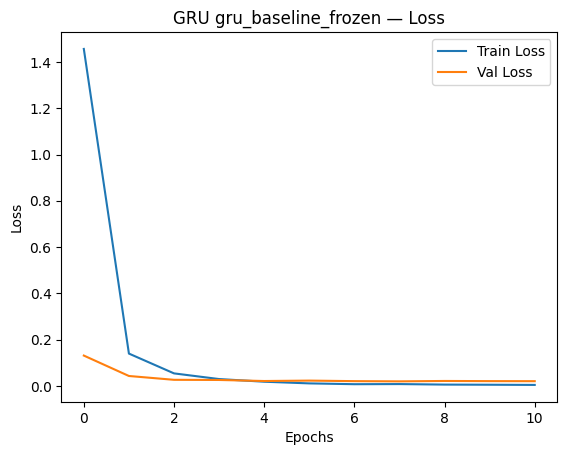

In [34]:
section("Select top GRU model")

best_gru_trial = gru_val_results_df.iloc[0]["trial_name"]
best_gru_model = gru_models[best_gru_trial]
best_gru_history = gru_histories[best_gru_trial]

print(f"Best GRU trial: {best_gru_trial}")
plot_history(best_gru_history, f"GRU {best_gru_trial}")

Test evaluation of hchosen GRU model

In [44]:
section("final GRU evaluation")

start=time.time()
y_proba_gru = best_gru_model.predict(X_test_seq, verbose=0)
test_time_gru = time.time()-start

y_pred_gru = y_proba_gru.argmax(axis=1)

gru_metrics = get_metrics(
    y_true=y_test,
    y_pred=y_pred_gru,
    y_proba=y_proba_gru,
    model_name="GRU",
    tier="Deep learning",
    time_s=test_time_gru
)

results["GRU"]= gru_metrics


final GRU evaluation

GRU — Test results:
  accuracy    : 0.9945
  precision   : 0.9946
  recall      : 0.9946
  f1          : 0.9945
  roc_auc     : 1.0000


GRU Classification and confusion Matrix

In [ ]:
section("GRU Classification and Confusion Matrix")

                          precision    recall  f1-score   support

            cancel_order       0.99      1.00      0.99       150
            change_order       0.99      0.98      0.98       149
 change_shipping_address       0.97      1.00      0.98       146
  check_cancellation_fee       1.00      1.00      1.00       142
           check_invoice       0.98      0.99      0.98       150
   check_payment_methods       1.00      0.99      1.00       150
     check_refund_policy       1.00      1.00      1.00       150
               complaint       1.00      1.00      1.00       150
contact_customer_service       1.00      0.99      1.00       150
     contact_human_agent       0.99      0.99      0.99       150
          create_account       0.99      0.99      0.99       150
          delete_account       1.00      1.00      1.00       149
        delivery_options       0.99      1.00      0.99       149
         delivery_period       1.00      0.99      1.00       150
         

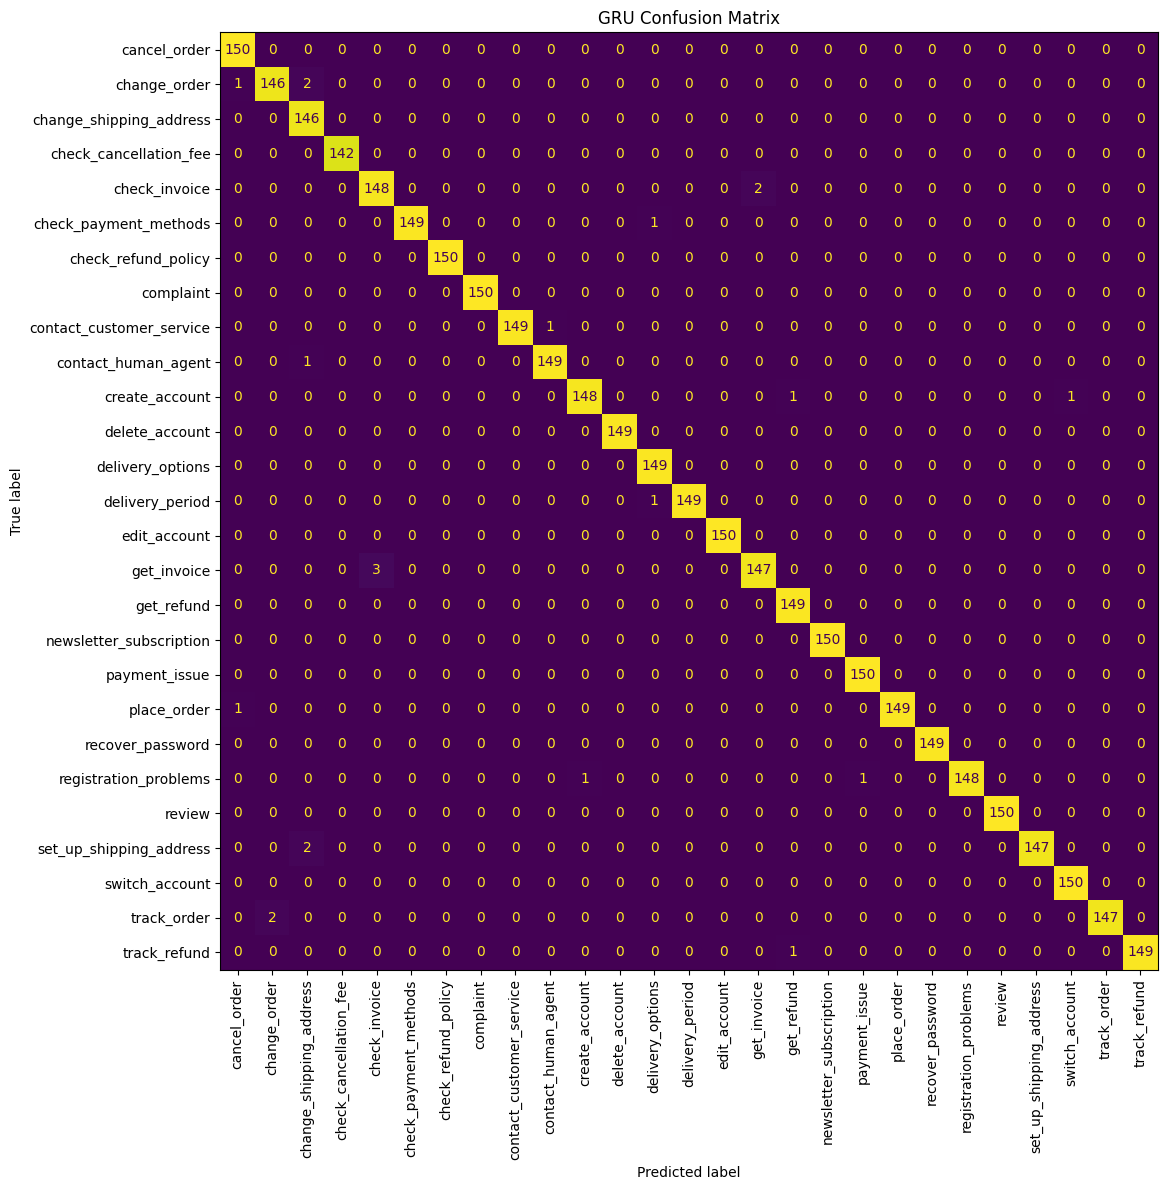

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test,y_pred_gru,target_names=le.classes_,))
cm= confusion_matrix(y_test,y_pred_gru)

fig, ax = plt.subplots(figsize=(14,12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=90, colorbar= False)
plt.title("GRU Confusion Matrix")
plt.tight_layout()
plt.show()